In [1]:
## config
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

con = duckdb.connect("healthcare.duckdb")

con.execute("PRAGMA threads=8")
con.execute("SET memory_limit='6GB'")

import matplotlib.font_manager as fm

font_path = "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc"

fm.fontManager.addfont(font_path)

font_name = fm.FontProperties(fname=font_path).get_name()

plt.rcParams["font.family"] = font_name
plt.rcParams["axes.unicode_minus"] = False

print(font_name)

Noto Sans CJK JP


# stage 1 - 약효분류군 시장 후보 선정

In [2]:
sql = """
CREATE OR REPLACE TABLE cluster_mefi AS

WITH yearly AS (
    SELECT
        meftDivNo,
        meftDivNoNm,

        SUM(
            CASE
                WHEN diagYm BETWEEN '202001' AND '202012'
                THEN msupUseAmt ELSE 0
            END
        ) AS amt_2020,

        SUM(
            CASE
                WHEN diagYm BETWEEN '202101' AND '202112'
                THEN msupUseAmt ELSE 0
            END
        ) AS amt_2021,

        SUM(
            CASE
                WHEN diagYm BETWEEN '202201' AND '202212'
                THEN msupUseAmt ELSE 0
            END
        ) AS amt_2022

    FROM mefi_sick

    WHERE diagYm BETWEEN '202001' AND '202212'
      AND insupTpCd IN ('4','5','7')

    GROUP BY
        meftDivNo,
        meftDivNoNm
),

metrics AS (
    SELECT
        *,
        amt_2022 - amt_2020 AS growth_amt,

        CASE
            WHEN amt_2020 > 0
            THEN amt_2022 / amt_2020 - 1
            ELSE NULL
        END AS cumulative_growth_rate,

        CASE
            WHEN amt_2020 > 0
             AND amt_2022 >= 0
            THEN POWER(amt_2022 / amt_2020, 0.5) - 1
            ELSE NULL
        END AS cagr_2y,

        CASE
            WHEN amt_2020 < amt_2021
             AND amt_2021 < amt_2022
            THEN 1
            ELSE 0
        END AS consistent_growth

    FROM yearly
),

ranked AS (
    SELECT
        *,
        RANK() OVER (
            ORDER BY amt_2022 DESC
        ) AS largest_rank,

        RANK() OVER (
            ORDER BY cagr_2y DESC NULLS LAST
        ) AS rapid_rank,

        RANK() OVER (
            ORDER BY
                consistent_growth DESC,
                cagr_2y DESC NULLS LAST
        ) AS consistent_rank

    FROM metrics
),

positioned AS (
    SELECT
        *,
        CASE
            WHEN largest_rank <= 20
             AND rapid_rank <= 20
             AND consistent_rank <= 20
                THEN '규모·성장·지속성 상위'

            WHEN largest_rank <= 20
             AND rapid_rank BETWEEN 21 AND 39
             AND cumulative_growth_rate > 0
                THEN '대형·성장 중위'

            WHEN largest_rank BETWEEN 21 AND 39
             AND consistent_rank <= 20
             AND cumulative_growth_rate > 0
                THEN '중대형·지속성장 상위'

            WHEN largest_rank > 39
             AND rapid_rank <= 20
             AND cumulative_growth_rate > 0
                THEN '소형·고성장'

            WHEN cumulative_growth_rate < 0
                THEN '역성장'

            ELSE '기타'
        END AS market_position

    FROM ranked
)

SELECT *
FROM positioned
;
"""

con.execute(sql)

sql1="""
CREATE OR REPLACE TABLE candidate_mefi  AS
select * 
from cluster_mefi
 WHERE market_position IN (
     '규모·성장·지속성 상위',
     '대형·성장 중위',
     '중대형·지속성장 상위',
     '소형·고성장'
 )
;
"""

con.execute(sql1)

In [3]:
sql_cluster_mefi_plt="""
select * 
from cluster_mefi
;
"""


mefi_position_df = con.execute(sql_cluster_mefi_plt).df()
mefi_position_df['market_position'].value_counts()

market_position
기타              40
역성장             34
소형·고성장          11
대형·성장 중위         8
중대형·지속성장 상위      4
규모·성장·지속성 상위     3
Name: count, dtype: int64

In [4]:
sql1_2 = """
SELECT
    meftDivNo,
    meftDivNoNm,
    amt_2020,
    amt_2021,
    amt_2022,
    growth_amt,
    cumulative_growth_rate,
    cagr_2y,
    consistent_growth,
    largest_rank,
    rapid_rank,
    consistent_rank,
    market_position
FROM candidate_mefi
ORDER BY
    largest_rank,
    rapid_rank;
"""
con.execute(sql1_2).df().head()

,meftDivNo,meftDivNoNm,amt_2020,amt_2021,amt_2022,growth_amt,cumulative_growth_rate,cagr_2y,consistent_growth,largest_rank,rapid_rank,consistent_rank,market_position
0,218,동맥경화용제,3.562780e+12,4.099093e+12,4.370894e+12,8.081140e+11,0.226821,0.107620,1,1,16,13,규모·성장·지속성 상위
1,214,혈압강하제,2.957579e+12,3.175095e+12,3.244751e+12,2.871725e+11,0.097097,0.047424,1,3,39,32,대형·성장 중위
2,232,소화성궤양용제,1.946299e+12,2.207121e+12,2.354223e+12,4.079245e+11,0.209590,0.099814,1,4,21,18,대형·성장 중위
3,119,기타의 중추신경용약,2.017405e+12,2.205743e+12,2.260376e+12,2.429714e+11,0.120438,0.058507,1,5,33,27,대형·성장 중위
4,396,당뇨병용제,1.912711e+12,2.113081e+12,2.236066e+12,3.233549e+11,0.169056,0.081229,1,6,28,24,대형·성장 중위


# stage 2 - ATC4군 시장 후보 선정

In [5]:
sql2_1 = """
DROP TABLE IF EXISTS candidate_atc4_ids;

CREATE TABLE candidate_atc4_ids AS

SELECT DISTINCT
    m.atc4cd
FROM prod_atc_map_named AS m

INNER JOIN candidate_mefi AS c
    ON c.meftDivNo = m.meftDivNo

WHERE m.atc4cd IS NOT NULL
and trim(m.atc4cd ) != ''
;

SELECT
    COUNT(*) AS candidate_atc4_count
FROM candidate_atc4_ids
;

"""

sql2_2 = """
SELECT *
FROM candidate_atc4_ids
ORDER BY atc4cd
LIMIT 100;
"""
candi_atc4_ids_cnt = con.execute(sql2_1).df()
candi_atc4_ids_df = con.execute(sql2_2).df()
print(candi_atc4_ids_cnt)
candi_atc4_ids_df.head()

   candidate_atc4_count
0                   200


,atc4cd
0,A01AB
1,A01AD
2,A02A
3,A02BA
4,A02BB


In [6]:
sql2_3 = """
DROP TABLE IF EXISTS cluster_atc4;

CREATE TABLE cluster_atc4 AS

WITH yearly AS (

    SELECT
        a.atcStep4Cd AS atc4cd,
        MAX(a.atcStep4CdNm) AS atc4cdNm,

        SUM(
            CASE
                WHEN a.diagYm BETWEEN '202001' AND '202012'
                THEN a.msupUseAmt ELSE 0
            END
        ) AS amt_2020,

        SUM(
            CASE
                WHEN a.diagYm BETWEEN '202101' AND '202112'
                THEN a.msupUseAmt ELSE 0
            END
        ) AS amt_2021,

        SUM(
            CASE
                WHEN a.diagYm BETWEEN '202201' AND '202212'
                THEN a.msupUseAmt ELSE 0
            END
        ) AS amt_2022

    FROM atc4_sick AS a

    INNER JOIN candidate_atc4_ids AS c
        ON a.atcStep4Cd = c.atc4cd

    WHERE a.diagYm BETWEEN '202001' AND '202212'
      AND a.insupTpCd IN ('4','5','7')

    GROUP BY
        a.atcStep4Cd
),

metrics AS (

    SELECT
        *,
        amt_2022 - amt_2020 AS growth_amt,

        CASE
            WHEN amt_2020 > 0
            THEN amt_2022 / amt_2020 - 1
            ELSE NULL
        END AS cumulative_growth_rate,

        CASE
            WHEN amt_2020 > 0
            THEN POWER(amt_2022 / amt_2020, 0.5) - 1
            ELSE NULL
        END AS cagr_2y,

        CASE
            WHEN amt_2020 < amt_2021
             AND amt_2021 < amt_2022
            THEN 1
            ELSE 0
        END AS consistent_growth

    FROM yearly
),

ranked AS (

    SELECT
        *,

        RANK() OVER (
            ORDER BY amt_2022 DESC
        ) AS size_rank,

        RANK() OVER (
            ORDER BY cagr_2y DESC NULLS LAST
        ) AS growth_rank,

        RANK() OVER (
            ORDER BY
                consistent_growth DESC,
                cagr_2y DESC NULLS LAST
        ) AS persistence_rank

    FROM metrics
)

SELECT
    *,
    CASE
        WHEN size_rank <= 10
         AND growth_rank <= 10
            THEN '규모·고성장'

        WHEN size_rank <= 10
            THEN '대형시장'

        WHEN growth_rank <= 10
            THEN '고성장시장'

        WHEN cumulative_growth_rate >= 0.05
            THEN '성장시장'

        ELSE '기타'
    END AS atc4_position

FROM ranked
;

select * from cluster_atc4 ;
"""

atc4_position_df = con.execute(sql2_3).df()
atc4_position_df['atc4_position'].value_counts()

atc4_position
성장시장     65
기타       62
고성장시장    10
대형시장     10
Name: count, dtype: int64

In [7]:
sql2_4 = """
DROP TABLE IF EXISTS candidate_atc4;

CREATE TABLE candidate_atc4 AS
SELECT * 
FROM cluster_atc4
WHERE size_rank <= 10
   OR growth_rank <= 10
   OR cumulative_growth_rate >= 0.05
   ;

SELECT
    atc4cd,
    atc4cdNm,
    amt_2020,
    amt_2021,
    amt_2022,
    growth_amt,
    cumulative_growth_rate,
    cagr_2y,
    consistent_growth,
    size_rank,
    growth_rank,
    persistence_rank,
    atc4_position
FROM candidate_atc4
ORDER BY
    size_rank,
    growth_rank;
"""


candidate_atc4_df = con.execute(sql2_4).df()
candidate_atc4_df.head()

,atc4cd,atc4cdNm,amt_2020,amt_2021,amt_2022,growth_amt,cumulative_growth_rate,cagr_2y,consistent_growth,size_rank,growth_rank,persistence_rank,atc4_position
0,C10AA,HMG CoA reductase inhibitors,1.683432e+12,1.790090e+12,1.753111e+12,6.967867e+10,0.041391,0.020486,0,1,85,86,대형시장
1,A02BC,Proton pump inhibitors,1.164324e+12,1.383735e+12,1.466112e+12,3.017878e+11,0.259196,0.122139,1,2,34,28,대형시장
2,C10BA,Combinations of various lipid modifying agents,8.610052e+11,1.148521e+12,1.444571e+12,5.835656e+11,0.677772,0.295289,1,3,12,9,대형시장
3,B01AC,Platelet aggregation inhibitors excl. heparin,1.262555e+12,1.385542e+12,1.366683e+12,1.041279e+11,0.082474,0.040420,0,4,81,84,대형시장
4,C09DB,Angiotensin II receptor blockers (ARBs) and ca...,1.108962e+12,1.221792e+12,1.305317e+12,1.963544e+11,0.177061,0.084925,1,5,53,45,대형시장


## compare : mefi <-> atc4  candidates 

In [8]:
sql2_extra = """
WITH mefi_atc4_link AS (

    SELECT 
        m.meftDivNo,
        m.atc4cd,
    FROM prod_atc_map_named AS m

    RIGHT JOIN candidate_mefi AS c
        ON c.meftDivNo = m.meftDivNo

    RIGHT JOIN candidate_atc4 AS a
        ON a.atc4cd = m.atc4cd

    WHERE m.atc4cd IS NOT NULL
    GROUP BY 1,2
)

SELECT
    l.meftDivNo,
    
    l.atc4cd,
    

    a.amt_2020,
    a.amt_2021,
    a.amt_2022,
    a.growth_amt,
    a.cumulative_growth_rate,
    a.cagr_2y,
    a.atc4_position

FROM mefi_atc4_link AS l

INNER JOIN candidate_atc4 AS a
    ON a.atc4cd = l.atc4cd

ORDER BY
    l.meftDivNo,
    a.size_rank;
"""

mefi_atc4_rel_df = con.execute(sql2_extra).df()
print(mefi_atc4_rel_df.shape)
mefi_atc4_rel_df.head()

(99, 9)


,meftDivNo,atc4cd,amt_2020,amt_2021,amt_2022,growth_amt,cumulative_growth_rate,cagr_2y,atc4_position
0,114,M09AX,4.273383e+11,4.523653e+11,5.027394e+11,7.540112e+10,0.176444,0.084640,성장시장
1,114,M01AE,3.177929e+11,3.340409e+11,4.535495e+11,1.357567e+11,0.427186,0.194649,성장시장
2,114,M01AX,2.510103e+11,2.776622e+11,2.956680e+11,4.465768e+10,0.177912,0.085316,성장시장
3,114,N02AJ,2.117675e+11,2.409635e+11,2.616108e+11,4.984334e+10,0.235368,0.111471,성장시장
4,114,M01AH,2.167360e+11,2.427898e+11,2.437491e+11,2.701308e+10,0.124636,0.060488,성장시장


## atc4 - disease analysis

In [9]:
sql2_d_1 = """
WITH disease_yearly AS (

    SELECT
        a.atcStep4Cd AS atc4cd,
        a.st3SickSym AS disease_cd,
        a.st3SickSymNm AS disease_nm,

        SUM(
            CASE
                WHEN a.diagYm BETWEEN '202001' AND '202012'
                THEN a.msupUseAmt ELSE 0
            END
        ) AS amt_2020,

        SUM(
            CASE
                WHEN a.diagYm BETWEEN '202201' AND '202212'
                THEN a.msupUseAmt ELSE 0
            END
        ) AS amt_2022

    FROM atc4_sick AS a

    INNER JOIN candidate_atc4 AS c
        ON a.atcStep4Cd = c.atc4cd

    WHERE a.diagYm BETWEEN '202001' AND '202212'
      AND a.insupTpCd IN ('4','5','7')

    GROUP BY
        a.atcStep4Cd,
        a.st3SickSym,
        a.st3SickSymNm
),

with_share AS (

    SELECT
        *,
        amt_2022 - amt_2020 AS growth_amt,

        CASE
            WHEN amt_2020 > 0
            THEN amt_2022 / amt_2020 - 1
            ELSE NULL
        END AS cumulative_growth_rate,

        CASE
            WHEN SUM(amt_2022) OVER (
                PARTITION BY atc4cd
            ) > 0
            THEN amt_2022
                 / SUM(amt_2022) OVER (
                     PARTITION BY atc4cd
                   )
            ELSE NULL
        END AS disease_share_2022

    FROM disease_yearly
)

SELECT
    *,
    POWER(disease_share_2022, 2) AS hhi_component

FROM with_share

ORDER BY
    atc4cd,
    disease_share_2022 DESC;
"""

disease_analysis_df = con.execute(sql2_d_1).df()
disease_analysis_df.head()

,atc4cd,disease_cd,disease_nm,amt_2020,amt_2022,growth_amt,cumulative_growth_rate,disease_share_2022,hhi_component
0,A01AD,AU07,U07의 응급사용,1876389.0,1.933603e+09,1.931727e+09,1029.491580,0.336028,0.112915
1,A01AD,AJ20,급성 기관지염,118331057.0,3.988241e+08,2.804930e+08,2.370409,0.069309,0.004804
2,A01AD,AJ03,급성 편도염,142683811.0,3.235417e+08,1.808579e+08,1.267543,0.056226,0.003161
3,A01AD,AJ02,급성 인두염,78876972.0,2.418342e+08,1.629572e+08,2.065967,0.042027,0.001766
4,A01AD,AJ06,다발성 및 상세불명 부위의 급성 상기도감염,94547171.0,2.191870e+08,1.246398e+08,1.318282,0.038091,0.001451


In [10]:
sql2_d_2 = """
WITH disease_share AS (

    SELECT
        a.atcStep4Cd AS atc4cd,
        a.st3SickSym AS disease_cd,

        SUM(a.msupUseAmt) AS amt

    FROM atc4_sick AS a

    INNER JOIN candidate_atc4 AS c
        ON a.atcStep4Cd = c.atc4cd

    WHERE a.diagYm BETWEEN '202201' AND '202212'
      AND a.insupTpCd IN ('4','5','7')

    GROUP BY
        a.atcStep4Cd,
        a.st3SickSym
),

share AS (

    SELECT
        *,
        amt / SUM(amt) OVER (
            PARTITION BY atc4cd
        ) AS disease_share

    FROM disease_share
)

SELECT
    atc4cd,

    SUM(
        POWER(disease_share, 2)
    ) AS hhi,

    COUNT(*) AS disease_count,

    MAX(disease_share) AS top1_disease_share

FROM share

GROUP BY
    atc4cd

ORDER BY
    hhi DESC;
"""

disease_hhi_df = con.execute(sql2_d_2).df()
disease_hhi_df.head()

,atc4cd,hhi,disease_count,top1_disease_share
0,D11AH,0.671542,917,0.816906
1,S01KA,0.557141,228,0.728790
2,S01EE,0.533443,870,0.726779
3,S01ED,0.469679,972,0.679467
4,S01EC,0.449151,676,0.664321


## atc4 - region analysis

In [11]:
sql_r_1 = """
WITH region_yearly AS (

    SELECT
        a.atcStep4Cd AS atc4cd,
        a.regionStep1Cd AS region_cd,
        a.regionStep1CdNm AS region_nm,

        SUM(
            CASE
                WHEN a.diagYm BETWEEN '202001' AND '202012'
                THEN a.msupUseAmt ELSE 0
            END
        ) AS amt_2020,

        SUM(
            CASE
                WHEN a.diagYm BETWEEN '202201' AND '202212'
                THEN a.msupUseAmt ELSE 0
            END
        ) AS amt_2022

    FROM atc4_region_inst AS a

    INNER JOIN candidate_atc4 AS c
        ON a.atcStep4Cd = c.atc4cd

    WHERE a.diagYm BETWEEN '202001' AND '202212'
      AND a.insupTpCd IN ('4','5','7')

    GROUP BY
        a.atcStep4Cd,
        a.regionStep1Cd,
        a.regionStep1CdNm
)

SELECT
    *,
    amt_2022 - amt_2020 AS growth_amt,

    CASE
        WHEN amt_2020 > 0
        THEN amt_2022 / amt_2020 - 1
        ELSE NULL
    END AS cumulative_growth_rate,

    CASE
        WHEN amt_2020 > 0
        THEN POWER(amt_2022 / amt_2020, 0.5) - 1
        ELSE NULL
    END AS cagr_2y

FROM region_yearly

ORDER BY
    atc4cd,
    amt_2022 DESC;
"""

region_analysis_df = con.execute(sql_r_1).df()
region_analysis_df.head()

,atc4cd,region_cd,region_nm,amt_2020,amt_2022,growth_amt,cumulative_growth_rate,cagr_2y
0,A01AD,31,경기,149447455.0,702275038.0,552827583.0,3.699144,1.167751
1,A01AD,31,서울,153699326.0,690637937.0,536938611.0,3.493435,1.119772
2,A01AD,81,경기,138496469.0,668023095.0,529526626.0,3.823394,1.196223
3,A01AD,81,서울,152135876.0,657077668.0,504941792.0,3.319019,1.078225
4,A01AD,01,서울,138792230.0,228620324.0,89828094.0,0.647213,0.283438


In [12]:
sql_r_2 = """
WITH institution_yearly AS (

    SELECT
        a.atcStep4Cd AS atc4cd,
        a.medInstType,

        SUM(
            CASE
                WHEN a.diagYm BETWEEN '202001' AND '202012'
                THEN a.msupUseAmt ELSE 0
            END
        ) AS amt_2020,

        SUM(
            CASE
                WHEN a.diagYm BETWEEN '202201' AND '202212'
                THEN a.msupUseAmt ELSE 0
            END
        ) AS amt_2022

    FROM atc4_region_inst AS a

    INNER JOIN candidate_atc4 AS c
        ON a.atcStep4Cd = c.atc4cd

    WHERE a.diagYm BETWEEN '202001' AND '202212'
      AND a.insupTpCd IN ('4','5','7')

    GROUP BY
        a.atcStep4Cd,
        a.medInstType
)

SELECT
    *,
    amt_2022 - amt_2020 AS growth_amt,

    CASE
        WHEN amt_2020 > 0
        THEN amt_2022 / amt_2020 - 1
        ELSE NULL
    END AS cumulative_growth_rate,

    CASE
        WHEN amt_2020 > 0
        THEN POWER(amt_2022 / amt_2020, 0.5) - 1
        ELSE NULL
    END AS cagr_2y

FROM institution_yearly

ORDER BY
    atc4cd,
    amt_2022 DESC;
"""

inst_analysis_df = con.execute(sql_r_2).df()
inst_analysis_df.head()

,atc4cd,medInstType,amt_2020,amt_2022,growth_amt,cumulative_growth_rate,cagr_2y
0,A01AD,약국,516382507.0,2.507053e+09,1.990670e+09,3.855031,1.203413
1,A01AD,의원,535177869.0,2.497449e+09,1.962271e+09,3.666577,1.160226
2,A01AD,종합병원,202892164.0,6.431038e+08,4.402117e+08,2.169683,0.780360
3,A01AD,병원,101261721.0,3.566162e+08,2.553545e+08,2.521728,0.876627
4,A01AD,상급종합병원,200209345.0,3.529495e+08,1.527401e+08,0.762902,0.327743


# Stage3 - Generic / Component 후보선정

candidate_atc4 --> prod_atc_map_named.mincmpcd --> cmpn_sick.gnlnmcd

In [13]:
sql_gn_1 = """
CREATE or REPLACE TABLE candidate_cmpn_ids AS

SELECT DISTINCT
    m.gnlNmCd AS gnlNmCd

FROM prod_atc_map_named AS m

INNER JOIN candidate_atc4 AS a
    ON a.atc4cd = m.atc4cd

WHERE m.gnlNmCd IS NOT NULL
;
SELECT 
    COUNT(*) AS candidate_cmpn_count
FROM candidate_cmpn_ids
;

"""
display(con.execute(sql_gn_1).df())
con.execute("select * from candidate_cmpn_ids order by gnlnmcd limit 10;").df()


,candidate_cmpn_count
0,1380


,gnlNmCd
0,100101APD
1,100102ACH
2,100430BIJ
3,100431BIJ
4,100701ACH
5,100702ATR
6,100901ACH
7,100901ACS
8,100901ATB
9,100903ATR


In [14]:
sql_gn_2 = """
CREATE or REPLACE TABLE candidate_cmpn AS

WITH yearly AS (

    SELECT
        c.gnlNmCd,
        MAX(c.gnlNmCdNm) AS gnlNmCdNm,

        SUM(
            CASE
                WHEN c.diagYm BETWEEN '202001' AND '202012'
                THEN c.msupUseAmt ELSE 0
            END
        ) AS amt_2020,

        SUM(
            CASE
                WHEN c.diagYm BETWEEN '202101' AND '202112'
                THEN c.msupUseAmt ELSE 0
            END
        ) AS amt_2021,

        SUM(
            CASE
                WHEN c.diagYm BETWEEN '202201' AND '202212'
                THEN c.msupUseAmt ELSE 0
            END
        ) AS amt_2022

    FROM cmpn_sick AS c

    INNER JOIN candidate_cmpn_ids AS x
        ON c.gnlNmCd = x.gnlNmCd

    WHERE c.diagYm BETWEEN '202001' AND '202212'
      AND c.insupTpCd IN ('4','5','7')

    GROUP BY
        c.gnlNmCd
),

metrics AS (

    SELECT
        *,
        amt_2022 - amt_2020 AS growth_amt,

        CASE
            WHEN amt_2020 > 0
            THEN amt_2022 / amt_2020 - 1
            ELSE NULL
        END AS cumulative_growth_rate,

        CASE
            WHEN amt_2020 > 0
            THEN POWER(amt_2022 / amt_2020, 0.5) - 1
            ELSE NULL
        END AS cagr_2y,

        CASE
            WHEN amt_2020 < amt_2021
             AND amt_2021 < amt_2022
            THEN 1
            ELSE 0
        END AS consistent_growth

    FROM yearly
),

ranked AS (

    SELECT
        *,
        RANK() OVER (
            ORDER BY amt_2022 DESC
        ) AS size_rank,

        RANK() OVER (
            ORDER BY cagr_2y DESC NULLS LAST
        ) AS growth_rank,

        RANK() OVER (
            ORDER BY
                consistent_growth DESC,
                cagr_2y DESC NULLS LAST
        ) AS persistence_rank

    FROM metrics
)

SELECT
    *,
    CASE
        WHEN size_rank <= 10
         AND growth_rank <= 10
            THEN '규모·고성장'

        WHEN size_rank <= 10
            THEN '대형시장'

        WHEN growth_rank <= 10
            THEN '고성장시장'

        WHEN cumulative_growth_rate >= 0.05
            THEN '성장시장'

        ELSE '기타'
    END AS cmpn_position

FROM ranked

WHERE size_rank <= 10
   OR growth_rank <= 10
   OR cumulative_growth_rate >= 0.05
   ;
SELECT
    gnlNmCd,
    gnlNmCdNm,
    amt_2020,
    amt_2021,
    amt_2022,
    growth_amt,
    cumulative_growth_rate,
    cagr_2y,
    consistent_growth,
    size_rank,
    growth_rank,
    persistence_rank,
    cmpn_position
FROM candidate_cmpn

ORDER BY
    size_rank,
    growth_rank
limit 3;
"""
con.execute(sql_gn_2).df()


,gnlNmCd,gnlNmCdNm,amt_2020,amt_2021,amt_2022,growth_amt,cumulative_growth_rate,cagr_2y,consistent_growth,size_rank,growth_rank,persistence_rank,cmpn_position
0,136901ATB,clopidogrel bisulfate (as clopidogrel),5.927188e+11,6.976033e+11,6.973929e+11,1.046741e+11,0.176600,0.084712,0,1,172,241,대형시장
1,138101ACS,choline alfoscerate,5.677875e+11,6.264633e+11,6.737587e+11,1.059712e+11,0.186639,0.089330,1,2,165,121,대형시장
2,111501ATB,atorvastatin calcium (as atorvastatin),6.414234e+11,6.655389e+11,6.629072e+11,2.148374e+10,0.033494,0.016609,0,3,249,266,대형시장


## compare : atc4 <-> generic candidates 

 - 1 : n relationships

In [15]:
"""
WITH atc4_cmpn_link AS (

    SELECT DISTINCT
        m.atc4cd,
        m.atc4cdNm,
        m.gnlNmCd AS gnlNmCd

    FROM prod_atc_map_named AS m

    INNER JOIN candidate_atc4 AS a
        ON a.atc4cd = m.atc4cd

    INNER JOIN candidate_cmpn AS c
        ON c.gnlNmCd = m.gnlNmCd

    WHERE m.atc4cd IS NOT NULL
      AND m.gnlNmCd IS NOT NULL
)

SELECT
    l.atc4cd,
    l.atc4cdNm,

    l.gnlNmCd,
    c.gnlNmCdNm,

    c.amt_2020,
    c.amt_2021,
    c.amt_2022,
    c.growth_amt,
    c.cumulative_growth_rate,
    c.cagr_2y,
    c.cmpn_position

FROM atc4_cmpn_link AS l

INNER JOIN candidate_cmpn AS c
    ON c.gnlNmCd = l.gnlNmCd

ORDER BY
    l.atc4cd,
    c.size_rank;
"""

'\nWITH atc4_cmpn_link AS (\n\n    SELECT DISTINCT\n        m.atc4cd,\n        m.atc4cdNm,\n        m.gnlNmCd AS gnlNmCd\n\n    FROM prod_atc_map_named AS m\n\n    INNER JOIN candidate_atc4 AS a\n        ON a.atc4cd = m.atc4cd\n\n    INNER JOIN candidate_cmpn AS c\n        ON c.gnlNmCd = m.gnlNmCd\n\n    WHERE m.atc4cd IS NOT NULL\n      AND m.gnlNmCd IS NOT NULL\n)\n\nSELECT\n    l.atc4cd,\n    l.atc4cdNm,\n\n    l.gnlNmCd,\n    c.gnlNmCdNm,\n\n    c.amt_2020,\n    c.amt_2021,\n    c.amt_2022,\n    c.growth_amt,\n    c.cumulative_growth_rate,\n    c.cagr_2y,\n    c.cmpn_position\n\nFROM atc4_cmpn_link AS l\n\nINNER JOIN candidate_cmpn AS c\n    ON c.gnlNmCd = l.gnlNmCd\n\nORDER BY\n    l.atc4cd,\n    c.size_rank;\n'

In [16]:
sql_test = """
SELECT
    gnlNmCd as gnlNmCd,
    COUNT(DISTINCT atc4cd) AS atc4_count

FROM prod_atc_map_named

WHERE gnlNmCd IS NOT NULL
  AND atc4cd IS NOT NULL

GROUP BY
    1
having  COUNT(DISTINCT atc4cd)> 1

ORDER BY
    atc4_count DESC;
"""
con.execute(sql_test).df()

,gnlNmCd,atc4_count
0,170131BIJ,2
1,140403BIJ,2
2,115502BIJ,2


In [17]:
sql_gn_3 = """
WITH candidate_products AS (

    SELECT DISTINCT
        m.gnlNmCd AS gnlNmCd,
        m.ProdCd,
        m.ProdNm,
        m.companyNm,
        m.meftDivNo,
        m.AtcCd,
        m.atc3cd,
        m.atc4cd

    FROM prod_atc_map_named AS m

    INNER JOIN candidate_cmpn AS c
        ON c.gnlNmCd = m.gnlNmCd

    WHERE m.ProdCd IS NOT NULL
)

SELECT
    p.gnlNmCd,
    c.gnlNmCdNm,

    p.ProdCd,
    p.ProdNm,
    p.companyNm,

    p.meftDivNo,
    p.AtcCd,
    p.atc3cd,
    p.atc4cd,

    c.amt_2022 AS cmpn_amt_2022,
    c.cumulative_growth_rate AS cmpn_growth_rate,
    c.cagr_2y AS cmpn_cagr,
    c.cmpn_position

FROM candidate_products AS p

INNER JOIN candidate_cmpn AS c
    ON c.gnlNmCd = p.gnlNmCd

ORDER BY
    c.size_rank,
    p.gnlNmCd,
    p.companyNm,
    p.ProdNm
LIMIT 2    
    ;
"""
con.execute(sql_gn_3).df()

,gnlNmCd,gnlNmCdNm,ProdCd,ProdNm,companyNm,meftDivNo,AtcCd,atc3cd,atc4cd,cmpn_amt_2022,cmpn_growth_rate,cmpn_cagr,cmpn_position
0,136901ATB,clopidogrel bisulfate (as clopidogrel),658106640,클로핀정(클로피도그렐황산염)_(97.875mg/1정),(유)한풍제약,218,B01AC04,B01A,B01AC,6.973929e+11,0.1766,0.084712,대형시장
1,136901ATB,clopidogrel bisulfate (as clopidogrel),665001700,경보클로피도그렐정(클로피도그렐황산염)_(97.875mg/1정),(주)경보제약,218,B01AC04,B01A,B01AC,6.973929e+11,0.1766,0.084712,대형시장


In [18]:
sql_gn_4 = """
SELECT
    m.gnlNmCd AS gnlNmCd,

    COUNT(DISTINCT m.ProdCd) AS product_count,
    COUNT(DISTINCT m.companyNm) AS company_count,
    COUNT(DISTINCT m.meftDivNo) AS mefi_count,
    COUNT(DISTINCT m.atc4cd) AS atc4_count

FROM prod_atc_map_named AS m

INNER JOIN candidate_cmpn AS c
    ON c.gnlNmCd = m.gnlNmCd

WHERE m.gnlNmCd IS NOT NULL

GROUP BY
    m.gnlNmCd

ORDER BY
    product_count DESC;
"""
con.execute(sql_gn_4).df()


,gnlNmCd,product_count,company_count,mefi_count,atc4_count
0,111501ATB,130,130,1,1
1,136901ATB,127,127,1,1
2,125201ACH,126,126,1,1
3,421001ATB,125,125,1,1
4,222901ATB,125,125,1,1
...,...,...,...,...,...
238,101801ACH,3,3,1,1
239,535300ASY,3,3,1,1
240,489602ACH,2,2,1,1
241,532100ASY,2,2,1,1


# full hierarchy : 약효분류군 -> atc4 -> generic

In [19]:
sql_hier = """
CREATE OR REPLACE VIEW final_market_hierarchy AS

WITH mefi_atc4 AS (

    SELECT DISTINCT
        m.meftDivNo,
        m.meftDivNoNm,
        m.atc4cd

    FROM prod_atc_map_named AS m

    INNER JOIN candidate_mefi AS mf
        ON mf.meftDivNo = m.meftDivNo

    INNER JOIN candidate_atc4 AS a
        ON a.atc4cd = m.atc4cd

    WHERE m.atc4cd IS NOT NULL
),

atc4_cmpn AS (

    SELECT DISTINCT
        m.atc4cd,
        m.atc4CdNm,
        m.gnlNmCd ,
        m.gnlNmCdNm

    FROM prod_atc_map_named AS m

    INNER JOIN candidate_atc4 AS a
        ON a.atc4cd = m.atc4cd

    INNER JOIN candidate_cmpn AS c
        ON c.gnlNmCd = m.gnlNmCd

    WHERE m.atc4cd IS NOT NULL
      AND m.gnlNmCd IS NOT NULL
)

SELECT
    mf.meftDivNo,
    mf.meftDivNoNm,

    mf.amt_2022 AS mefi_amt_2022,
    mf.cagr_2y AS mefi_cagr,
    mf.cumulative_growth_rate AS mefi_growth,
    mf.market_position AS mefi_position,

    a.atc4cd,
    a.atc4cdNm,
    a.amt_2022 AS atc4_amt_2022,
    a.cagr_2y AS atc4_cagr,
    a.cumulative_growth_rate AS atc4_growth,
    a.atc4_position,

    c.gnlNmCd,
    c.gnlNmCdNm,
    c.amt_2022 AS cmpn_amt_2022,
    c.cagr_2y AS cmpn_cagr,
    c.cumulative_growth_rate AS cmpn_growth,
    c.cmpn_position

FROM mefi_atc4 AS link

INNER JOIN candidate_mefi AS mf
    ON mf.meftDivNo = link.meftDivNo

INNER JOIN candidate_atc4 AS a
    ON a.atc4cd = link.atc4cd

LEFT JOIN atc4_cmpn AS ac
    ON ac.atc4cd = a.atc4cd

LEFT JOIN candidate_cmpn AS c
    ON c.gnlNmCd = ac.gnlNmCd
;
SELECT * FROM final_market_hierarchy limit 1;
"""
con.execute(sql_hier).df()


,meftDivNo,meftDivNoNm,mefi_amt_2022,mefi_cagr,mefi_growth,mefi_position,atc4cd,atc4cdNm,atc4_amt_2022,atc4_cagr,atc4_growth,atc4_position,gnlNmCd,gnlNmCdNm,cmpn_amt_2022,cmpn_cagr,cmpn_growth,cmpn_position
0,237,정장제,9.144217e+10,0.16902,0.366609,소형·고성장,A07DA,Antipropulsives,1.239822e+09,0.068783,0.142298,성장시장,185102ACH,loperamide hydrochloride,1.239820e+09,0.068784,0.142298,성장시장


https://chatgpt.com/s/t_6ab24ad5a3588191b9a5bb4e5c86ccf1

# visualize

## 

Noto Sans CJK JP


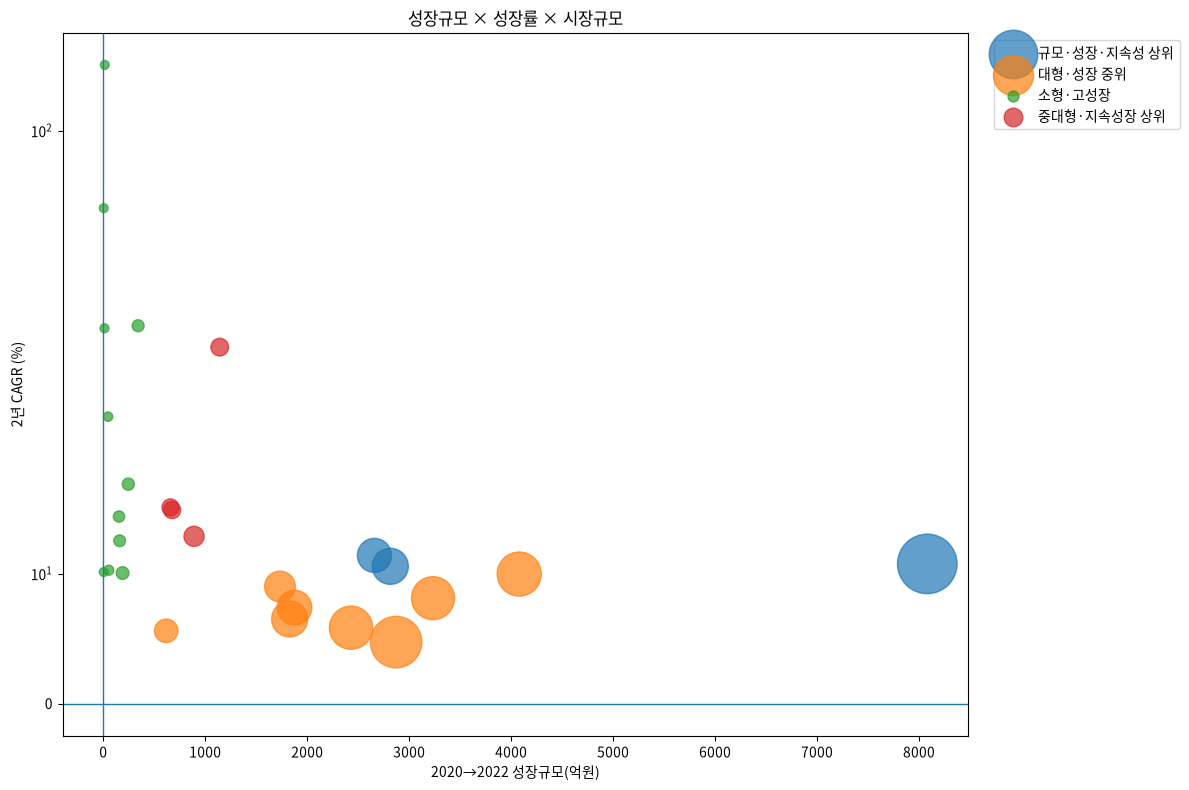

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_path = "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc"

fm.fontManager.addfont(font_path)

font_name = fm.FontProperties(fname=font_path).get_name()

plt.rcParams["font.family"] = font_name
plt.rcParams["axes.unicode_minus"] = False

print(font_name)


###
df = pd.read_parquet(
    "presentation_output/slide03_mefi_scatter.parquet"
)

plt.figure(figsize=(12, 8))
size = (
    df["amt_2022"] / df["amt_2022"].max()
) * 1800 + 40

import numpy as np

for position, group in df.groupby("market_position"):

    idx = group.index

    plt.scatter(
        group["growth_amt"]/1e8,
        group["cagr_2y"]*100,
        s=size.loc[idx],
        alpha=0.7,
        label=position
    )

plt.yscale('symlog', linthresh=30.0) 

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)

plt.xlabel("2020→2022 성장규모(억원)")
plt.ylabel("2년 CAGR (%)")
plt.title("성장규모 × 성장률 × 시장규모")

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.savefig(
    "presentation_output/slide03_market_matrix.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

/tmp/ipykernel_7063/155803457.py:69: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


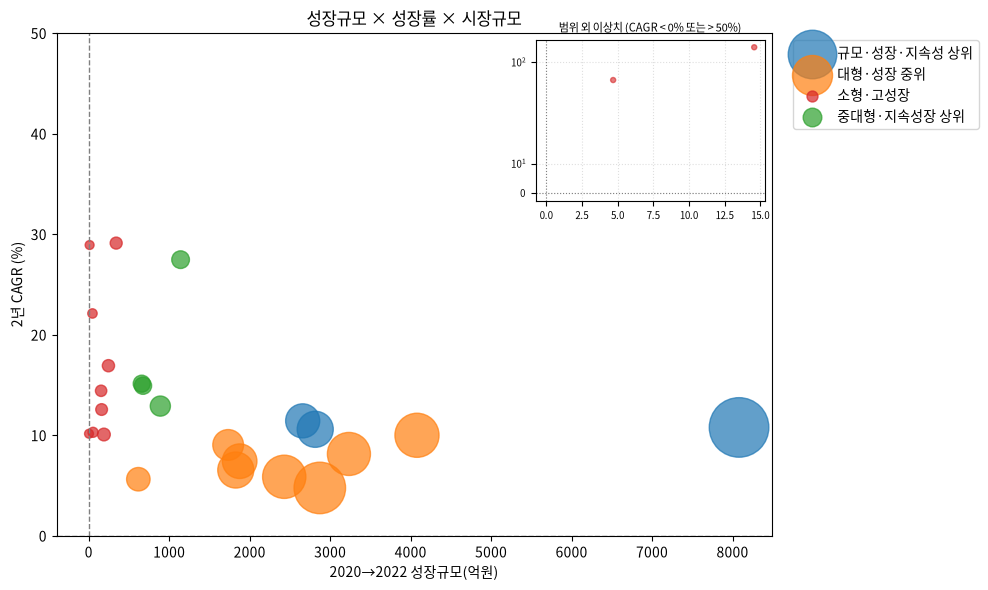

In [18]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# 1. Figure 및 메인 Axes 생성
fig, ax = plt.subplots(figsize=(10, 6))

# 카테고리별 색상을 고정하기 위한 Color Map 생성 (Matplotlib 기본 팔레트 활용)
positions = df["market_position"].unique()
colors = plt.cm.tab10.colors  # 기본 10가지 색상 팔레트
color_map = {pos: colors[i % len(colors)] for i, pos in enumerate(positions)}

# 2. 메인 그래프 데이터 플롯 (CAGR 0% ~ 50% 중심)
for position, group in df.groupby("market_position"):
    idx = group.index
    ax.scatter(
        group["growth_amt"] / 1e8,
        group["cagr_2y"] * 100,
        s=size.loc[idx],
        alpha=0.7,
        label=position,
        color=color_map[position]  # 고정된 색상 지정
    )

# 메인 그래프 Y축 확대 범위 설정 (0% ~ 50%)
ax.set_ylim(0, 50) 

# 축 기준선 및 레이블 설정
ax.axhline(0, color="gray", linewidth=1, linestyle="--")
ax.axvline(0, color="gray", linewidth=1, linestyle="--")

ax.set_xlabel("2020→2022 성장규모(억원)")
ax.set_ylabel("2년 CAGR (%)")
ax.set_title("성장규모 × 성장률 × 시장규모")

ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

# 3. 인셋 플롯(미니 맵) 생성 - 확대 범위 외(Outlier) 값만 플롯
ax_ins = inset_axes(ax, width="32%", height="32%", loc="upper right")

for position, group in df.groupby("market_position"):
    cagr_pct = group["cagr_2y"] * 100
    
    # 메인 그래프 범위(0 ~ 50)를 벗어난 데이터만 필터링
    outlier_mask = (cagr_pct < 0) | (cagr_pct > 50)
    outlier_group = group[outlier_mask]
    
    if not outlier_group.empty:
        idx_outlier = outlier_group.index
        ax_ins.scatter(
            outlier_group["growth_amt"] / 1e8,
            cagr_pct[outlier_mask],
            s=size.loc[idx_outlier] / 3,
            alpha=0.6,
            color=color_map[position]  # 메인 그래프와 동일한 색상 지정
        )

# 미니 맵 스케일 및 스타일 설정 (이상치 전용)
ax_ins.set_yscale('symlog', linthresh=30.0)
ax_ins.axhline(0, color="gray", linewidth=0.8, linestyle=":")
ax_ins.axvline(0, color="gray", linewidth=0.8, linestyle=":")
ax_ins.set_title("범위 외 이상치 (CAGR < 0% 또는 > 50%)", fontsize=8)
ax_ins.tick_params(axis='both', which='major', labelsize=7)
ax_ins.grid(True, linestyle=":", alpha=0.4)

# 4. 저장 및 출력
plt.tight_layout()
plt.savefig(
    "presentation_output/slide03_market_matrix.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

##

In [4]:
import pandas as pd
import numpy as np

base = "presentation_output/"

mefi = pd.read_parquet(base + "slide02_mefi_all.parquet")
atc4 = pd.read_parquet(base + "slide04_atc4_all.parquet")
cmpn = pd.read_parquet(base + "slide07_cmpn_all.parquet")
region = pd.read_parquet(base + "slide06_region_top10.parquet")
institution = pd.read_parquet(base + "slide06_institution.parquet")

def krw_unit(x):

    if abs(x) >= 1e12:
        return f"{x / 1e12:.1f}조원"

    elif abs(x) >= 1e8:
        return f"{x / 1e8:.0f}억원"

    elif abs(x) >= 1e4:
        return f"{x / 1e4:.0f}만원"

    else:
        return f"{x:,.0f}원"

print("=" * 70)
print("PRESENTATION KEY NUMBERS")
print("=" * 70)


# ------------------------------------------------------------
# MEFI
# ------------------------------------------------------------

print("\n[SLIDE 2] MEFI")

print("후보 시장 수:", len(mefi))

print(
    "2022 Top 10 시장규모:",
    f"{mefi.head(10)['amt_2022'].sum():,.0f}"
)

print(
    "양의 CAGR 시장 수:",
    (mefi["cagr_2y"] > 0).sum()
)

print(
    "지속 성장 시장 수:",
    mefi["consistent_growth"].sum()
)


# ------------------------------------------------------------
# Market Position
# ------------------------------------------------------------

print("\n[SLIDE 3] MARKET POSITION")

print(
    mefi["market_position"]
    .value_counts()
    .to_string()
)


# ------------------------------------------------------------
# ATC4
# ------------------------------------------------------------

print("\n[SLIDE 4] ATC4")

print("ATC4 후보 수:", len(atc4))

print(
    "Top 10 2022 시장규모:",
    f"{atc4.head(10)['amt_2022'].sum():,.0f}"
)

print("\nTop 10")

print(
    mefi.head(10)[
        ["meftDivNoNm", "amt_2022", "cagr_2y", "market_position"]
    ].to_string(index=False)
)


# ------------------------------------------------------------
# Component
# ------------------------------------------------------------

print("\n[SLIDE 7] COMPONENT")

print("Component 후보 수:", len(cmpn))

print(
    "Top 10 component observed amount:",
    f"{cmpn.head(10)['amt_2022'].sum():,.0f}"
)

print("\nTop 10 components")

print(
    cmpn.head(10)[
        ["gnlNmCdNm", "amt_2022", "cagr_2y", "cmpn_position"]
    ].to_string(index=False)
)


# ------------------------------------------------------------
# Region
# ------------------------------------------------------------

print("\n[SLIDE 6] REGION")

print(region.to_string(index=False))


# ------------------------------------------------------------
# Institution
# ------------------------------------------------------------

print("\n[SLIDE 6] INSTITUTION")

print(institution.to_string(index=False))

PRESENTATION KEY NUMBERS

[SLIDE 2] MEFI
후보 시장 수: 26
2022 Top 10 시장규모: 21,420,024,292,170
양의 CAGR 시장 수: 26
지속 성장 시장 수: 24

[SLIDE 3] MARKET POSITION
market_position
소형·고성장          11
대형·성장 중위         8
중대형·지속성장 상위      4
규모·성장·지속성 상위     3

[SLIDE 4] ATC4
ATC4 후보 수: 85
Top 10 2022 시장규모: 11,163,763,667,097

Top 10
         meftDivNoNm     amt_2022  cagr_2y market_position
              동맥경화용제 4.370894e+12 0.107620    규모·성장·지속성 상위
               혈압강하제 3.244751e+12 0.047424        대형·성장 중위
             소화성궤양용제 2.354223e+12 0.099814        대형·성장 중위
          기타의 중추신경용약 2.260376e+12 0.058507        대형·성장 중위
               당뇨병용제 2.236066e+12 0.081229        대형·성장 중위
           해열·진통·소염제 1.545192e+12 0.105772    규모·성장·지속성 상위
 주로 그람양성,음성균에 작용하는 것 1.539382e+12 0.065231        대형·성장 중위
  따로 분류되지 않는 대사성 의약품 1.409214e+12 0.074032        대형·성장 중위
                안과용제 1.367577e+12 0.114163    규모·성장·지속성 상위
자격료법제(비특이성면역원제제를 포함) 1.092349e+12 0.090210        대형·성장 중위

[SLIDE 7] COMPONENT
Component 후보 수

##

## 

## 

## 